# Support Vector Machine

* Working mechanism --> to find the best boundary(hyperplane), that separates two classes by maximizing the margin between them.


* Hyperplane --> decision boundary separating different classes in the feature space.

    represented mathematically by the equation

        wx+b=0


* Margin --> distance between the hyperplane and the closest data points, which are called support vectors.

* larger the margin, the better the model performs on new and unseen data.


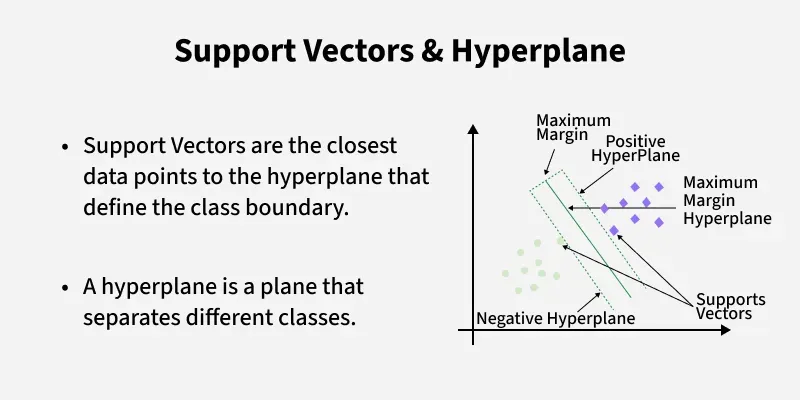

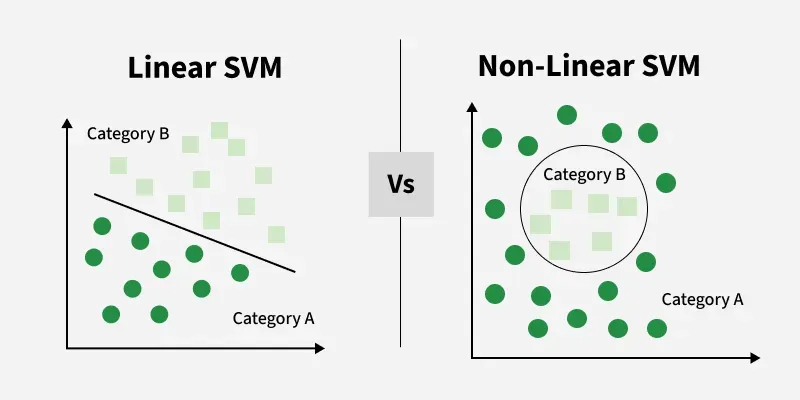

To find the hyperplane that best separates two classes by maximizing the margin between them.

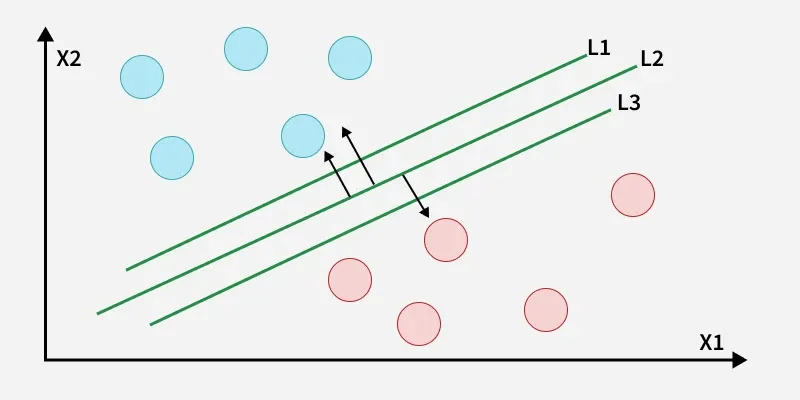

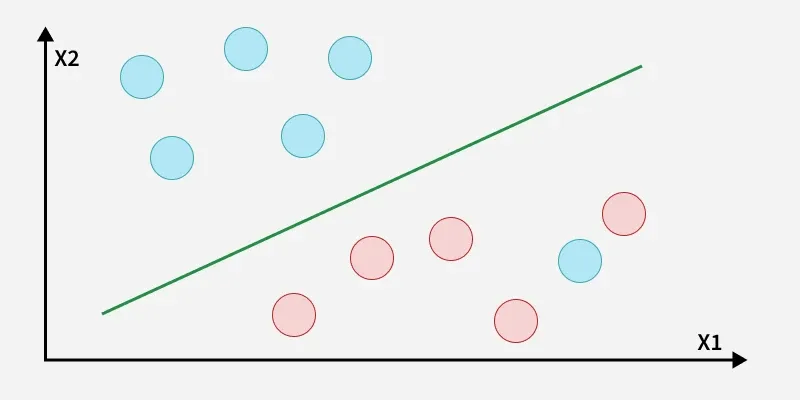

soft margin allows for some misclassifications or violations of the margin to improve generalization

SVM optimizes the following equation to balance margin maximization and penalty minimization:

    Objective Function = (1/margin) + λ ∑ penalty

The penalty used for violations is often hinge loss which has the following behavior:

* If a data point is correctly classified and within the margin there is no penalty (loss = 0).
* If a point is incorrectly classified or violates the margin the hinge loss increases proportionally to the distance of the violation.

### Not linearly separable

SVM uses a technique called kernels to map the data into a higher-dimensional space where it becomes separable.

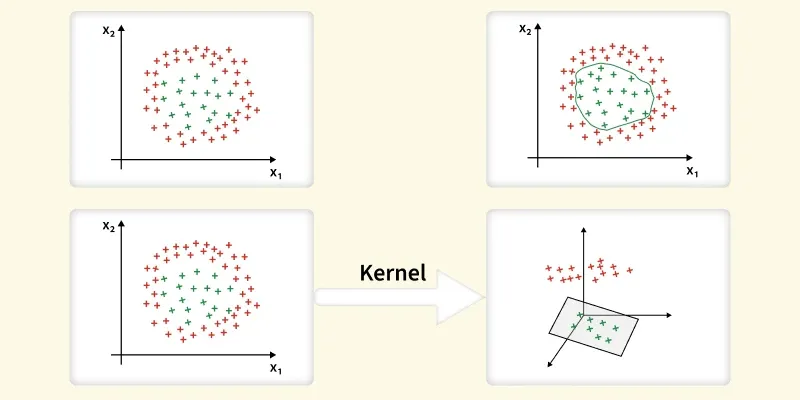

    kernel is a function that maps data points into a higher-dimensional space without explicitly computing the coordinates in that space.

    By applying a kernel function SVM transforms the data points into a higher-dimensional space where they become linearly separable.

* Linear Kernel: For linear separability.
* Polynomial Kernel: Maps data into a polynomial space.
* Radial Basis Function (RBF) Kernel: Transforms data into a space based on distances between data points.

In [ ]:
import pandas as pd
df=pd.read_csv("/content/height_classification.csv")
df.head()

{'whiskers': [<matplotlib.lines.Line2D at 0x7ac4e3f8b0e0>,
 'caps': [<matplotlib.lines.Line2D at 0x7ac4e3f8b740>,
 'boxes': [<matplotlib.lines.Line2D at 0x7ac4e3a0b500>],
 'medians': [<matplotlib.lines.Line2D at 0x7ac4e3f8bd40>],
 'fliers': [<matplotlib.lines.Line2D at 0x7ac4e3f7c0b0>],
 'means': []}

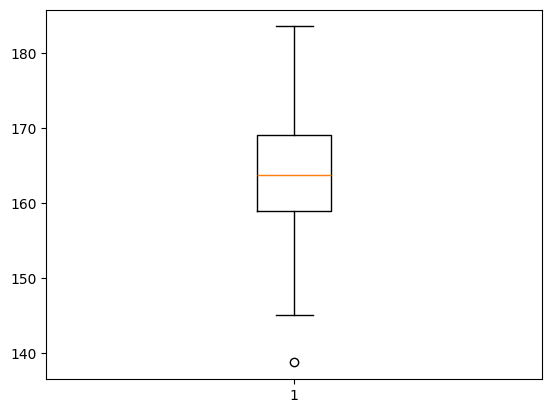

In [ ]:
import matplotlib.pyplot as plt
plt.boxplot(df['Height_cm'])

In [ ]:
x=df[['Height_cm']]
y=df['Category']


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.svm import SVC

svc=SVC(kernel='linear')

svc.fit(x_train,y_train)


In [ ]:
test_prediction=pd.DataFrame({"Height_cm":[180,134,155,177,190]})

test_prediction

,Height_cm
0,180
1,134
2,155
3,177
4,190


In [ ]:
y_test_pred=svc.predict(test_prediction)



array(['Taller', 'Short', 'Short', 'Taller', 'Taller'], dtype=object)

In [ ]:
y_test_pred =pd.DataFrame(y_test_pred,columns=['Predicted'],index=test_prediction.index)
y_test_pred

,Predicted
0,Taller
1,Short
2,Short
3,Taller
4,Taller


In [ ]:
merged= pd.concat((test_prediction,y_test_pred),axis=1)

merged

,Height_cm,Predicted
0,180,Taller
1,134,Short
2,155,Short
3,177,Taller
4,190,Taller


In [ ]:
merged_dataset=pd.concat((df,merged), join="outer")
merged_dataset

,Height_cm,Category,Predicted
0,170.0,Taller,NaN
1,163.6,Short,NaN
2,171.5,Taller,NaN
3,180.2,Taller,NaN
4,162.7,Short,NaN
...,...,...,...
0,180.0,NaN,Taller
1,134.0,NaN,Short
2,155.0,NaN,Short
3,177.0,NaN,Taller


In [ ]:
merged_dataset.to_csv("height_class.csv", index=False)

In [ ]:
merged_dataset.isnull().sum()

,0
Height_cm,0
Category,5
Predicted,100


In [ ]:

y_pred=svc.predict(x_test)

In [ ]:
y_pred

array(['Short', 'Taller', 'Short', 'Short', 'Short', 'Short', 'Short',
       'Short', 'Short', 'Taller', 'Short', 'Short', 'Taller', 'Short',
       'Short', 'Short', 'Short', 'Short', 'Short', 'Taller'],
      dtype=object)

In [ ]:
y_pred=pd.DataFrame(y_pred,columns=['Predicted'], index=x_test.index)
display(y_pred.shape)
display(y_test.shape)
display(x_test.shape)

(20, 1)

(20,)

(20, 1)

In [ ]:
df['Category'].value_counts()

,count
Category,
Short,75
Taller,25


In [ ]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
acc=accuracy_score(y_test,y_pred)
print(acc)
con=confusion_matrix(y_test,y_pred)
print(con)
rep=classification_report(y_test,y_pred)
print(rep)

1.0
[[16  0]
 [ 0  4]]
              precision    recall  f1-score   support

       Short       1.00      1.00      1.00        16
      Taller       1.00      1.00      1.00         4

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



In [ ]:
dataset_dia=pd.read_csv("/content/diabetes.csv")
dataset_dia

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [ ]:
dataset_height=pd.read_csv("/content/height_classification.csv")

dataser_height_class= pd.read_csv("/content/height_class.csv")

dataser_height_class

,Height_cm,Category,Predicted
0,170.0,Taller,NaN
1,163.6,Short,NaN
2,171.5,Taller,NaN
3,180.2,Taller,NaN
4,162.7,Short,NaN
...,...,...,...
100,180.0,NaN,Taller
101,134.0,NaN,Short
102,155.0,NaN,Short
103,177.0,NaN,Taller


In [ ]:
dataset_height

,Height_cm,Category
0,170.0,Taller
1,163.6,Short
2,171.5,Taller
3,180.2,Taller
4,162.7,Short
...,...,...
95,150.4,Short
96,168.0,Short
97,167.6,Short
98,165.1,Short


In [ ]:
merged = pd.concat((dataset_dia,dataset_height,dataser_height_class), axis=1)

In [ ]:
merged

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Height_cm,Category,Height_cm,Category,Predicted
0,6,148,72,35,0,33.6,0.627,50,1,170.0,Taller,170.0,Taller,NaN
1,1,85,66,29,0,26.6,0.351,31,0,163.6,Short,163.6,Short,NaN
2,8,183,64,0,0,23.3,0.672,32,1,171.5,Taller,171.5,Taller,NaN
3,1,89,66,23,94,28.1,0.167,21,0,180.2,Taller,180.2,Taller,NaN
4,0,137,40,35,168,43.1,2.288,33,1,162.7,Short,162.7,Short,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0,NaN,NaN,NaN,NaN,NaN
764,2,122,70,27,0,36.8,0.340,27,0,NaN,NaN,NaN,NaN,NaN
765,5,121,72,23,112,26.2,0.245,30,0,NaN,NaN,NaN,NaN,NaN
766,1,126,60,0,0,30.1,0.349,47,1,NaN,NaN,NaN,NaN,NaN


In [ ]:
merged.to_csv("Merged Dataset.csv", index=False)

In [ ]:
merge= pd.merge(dataset_height,dataser_height_class, on="Height_cm")

merge

,Height_cm,Category_x,Category_y,Predicted
0,170.0,Taller,Taller,NaN
1,163.6,Short,Short,NaN
2,171.5,Taller,Taller,NaN
3,180.2,Taller,Taller,NaN
4,162.7,Short,Short,NaN
...,...,...,...,...
129,165.1,Short,Short,NaN
130,162.7,Short,Short,NaN
131,162.7,Short,Short,NaN
132,162.7,Short,Short,NaN


In [ ]:
dataset_dia

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [ ]:
x=dataset_dia.drop(columns=['Outcome'])
y=dataset_dia['Outcome']

In [ ]:
from sklearn.model_selection import train_test_split

train_x,test_x,train_y,test_y=train_test_split(x,y,test_size=.3,random_state=32)

print(train_x.shape,test_x.shape,train_y.shape,test_y.shape)

(537, 8) (231, 8) (537,) (231,)


In [ ]:
from sklearn.svm import SVC

model_svm=SVC(kernel='linear')


model_svm.fit(train_x,train_y)

SVC(kernel='linear')

In [ ]:
prediction=model_svm.predict(test_x)
prediction

array([0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0,
       0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0,
       0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0])

In [ ]:
prediction=pd.DataFrame(prediction, columns=["prediction"],index=test_x.index)

prediction

,prediction
642,0
695,0
453,0
565,0
99,0
...,...
455,1
354,0
216,0
509,0


In [ ]:
from sklearn.metrics import accuracy_score,classification_report

In [ ]:
print(accuracy_score(prediction,test_y))

0.7705627705627706


In [ ]:
print(classification_report(prediction,test_y))

              precision    recall  f1-score   support

           0       0.90      0.78      0.83       170
           1       0.55      0.75      0.63        61

    accuracy                           0.77       231
   macro avg       0.72      0.77      0.73       231
weighted avg       0.81      0.77      0.78       231



Linear kernels:

    Suitable for high-dimensional data or linearly separable data.
    Computes the dot product of input vectors, efficient for large feature sets.
    Simple and often used as a baseline for comparison.

RBF kernel:

    Default choice for non-linear problems in SVMs.
    Captures complex relationships without prior knowledge of data.
    Sensitive to hyperparameter tuning, especially gamma.

Polynomial kernels:

    Effective for problems with polynomial patterns.
    Commonly used in computer vision and image recognition.
    Degree parameter controls the complexity of the polynomial.

Sigmoid kernel:

    Useful for neural network applications.
    Appropriate when data distribution resembles a sigmoid.
    Requires careful tuning of parameters for best performance.